In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
from pathlib import Path


In [ ]:
data_name = "dayu13A"
data = get_data(data_name)
config, config_str = get_hmc_config(find_min = False, bias = "unified", cap = False, temp = True, umbrella = False)
find_min_config, config_find_min_str = get_hmc_config(find_min = True)

mid_name = f"{config_find_min_str}"
if config["rsp"]:
    mid_name = f"seed{config["sd"]}"

if config["ns"]>=100000:    
    os.makedirs(f"../../../../pics/{data_name}/{mid_name}/{config_str}", exist_ok=True)
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))
print(config["nl"])

None


In [3]:
base_dir = Path.cwd()

samples = (base_dir / f"../../../../output/{data_name}/{mid_name}/{config_str}/samples.npy").resolve()
energy_values = (base_dir / f"../../../../output/{data_name}/{mid_name}/{config_str}/energy.npy").resolve()
bias_values = (base_dir / f"../../../../output/{data_name}/{mid_name}/{config_str}/bias.npy").resolve()
resampled_samples = (base_dir / f"../../../../output/{data_name}/{mid_name}/{config_str}/resamp.npy").resolve()
energy_values = (base_dir / f"../../../../output/{data_name}/{mid_name}/{config_str}/energy.npy").resolve()


samples = np.load(samples)
energy_values = np.load(energy_values)
bias_values = np.load(bias_values)
resampled_samples = np.load(resampled_samples)


In [4]:
print(energy_values)

[[67.07310492 73.67730545 74.98919336 ... 68.03784954 61.23442166
  63.56809086]
 [61.53978694 52.15050662 56.20735777 ... 40.6708166  40.34654024
  39.81410301]
 [68.42826232 63.88584355 68.38270858 ... 59.33703915 64.70462223
  67.66595626]
 [69.49448829 57.71892991 64.81116187 ... 40.97901859 45.85080375
  39.23717626]
 [66.16657637 69.50069309 68.63011457 ... 87.64944544 78.60810415
  71.80692243]]


In [5]:
nl = config["nl"] if config["nl"] != None else 1
nl2 = config["nl"] if config["npc"] == 2 else 1
nt = config["nt"] if config["nt"] != None else 1
print(config["nl"])


None


In [6]:
print("Reweighting energies for each temp\n")

if nt > 1 or config["ai"] or config["unb"]:
    factors = np.arange(nt) / (nt - 1)

    if config["ai"]:
        start_temps = (base_dir / f"../../../../output/{data_name}/start_Ts.npy").resolve()
        temp_centers = np.load(start_temps)
        nt = len(temp_centers)
    elif config["unb"]:
        start_temps = (base_dir / f"../../../../output/{data_name}/{mid_name}/temps_sbt{config["sbt"]}_ebt{config["ebt"]}.npy").resolve()
        temp_centers = np.load(start_temps)
        nt = len(temp_centers)
    else:
        temp_centers = config["sbt"] + ((config["ebt"] - config["sbt"]) * factors) if config["ut"] else config["sbt"] * (config["ebt"] / config["sbt"]) ** factors
    temp_colors = plt.cm.viridis(np.linspace(0,1, nt))

    # Compute betas
    betas = 1.0 / temp_centers

    # Initial beta
    beta0 = 1.0
    energy_samples = []
    weights = []

    for j in range(nt):
        temp_energy_samples = []
        weights = np.exp(-(betas[j] - beta0) * energy_values + bias_values)
        for i in range(config["nch"]):
            weights_i = weights[i, config["co"]:] / sum(weights[i, config["co"]:])
            indices = np.random.choice(
                np.arange(config["co"], len(weights_i) + config["co"]),
                size=int(len(weights_i)),
                replace=True,
                p=weights_i,
            )
            print(f"Chain {i} done resampling")
            temp_energy_samples.append(energy_values[i, indices])
        energy_samples.append(temp_energy_samples)
            
    energy_samples = np.array(energy_samples)
    print(np.shape(energy_samples))

Reweighting energies for each temp



C:\Users\hanna\AppData\Local\Temp\ipykernel_12604\721329277.py:4: RuntimeWarning: invalid value encountered in divide
  factors = np.arange(nt) / (nt - 1)


Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done res

In [7]:
if (nt > 1 or nl > 1):
    base_dir = Path.cwd()

    files = [(base_dir / f"../../../../output/{data_name}/{mid_name}/{config_str}/deltaF_chain{i}.bin").resolve() for i in range(config["nch"])]

    stride = 10000
    deltaF = []

    for f in files:
        print(f)
        dF_data = np.fromfile(f, dtype=np.float64)
        print(np.shape(dF_data))
        # reshape to full dimensions first
        first_dim = int(config["ns"]/stride) if int(config["ns"]/stride) != 0 else 1
        dF_data = dF_data.reshape(first_dim, nl, nl2, nt)
        # take every 10th element along the first axis
        deltaF.append(dF_data)

    deltaF = np.array(deltaF)
    print(deltaF.shape)

C:\Users\hanna\Desktop\PhD\Bacon\output\dayu13A\N15_H30_dc2_dt0.005_ns100_ndt10_nHMC10_a1.5_b0.21_nlsp100_mi100_gl0.0001_hmc_sd42_adt0.0001\N15_H30_dc2_dt0.007_ns1000000_co10_ndt10_nHMC10_nch5_a1.5_b0.21_dE50_sd42_ai\deltaF_chain0.bin
(2200,)
C:\Users\hanna\Desktop\PhD\Bacon\output\dayu13A\N15_H30_dc2_dt0.005_ns100_ndt10_nHMC10_a1.5_b0.21_nlsp100_mi100_gl0.0001_hmc_sd42_adt0.0001\N15_H30_dc2_dt0.007_ns1000000_co10_ndt10_nHMC10_nch5_a1.5_b0.21_dE50_sd42_ai\deltaF_chain1.bin
(2200,)
C:\Users\hanna\Desktop\PhD\Bacon\output\dayu13A\N15_H30_dc2_dt0.005_ns100_ndt10_nHMC10_a1.5_b0.21_nlsp100_mi100_gl0.0001_hmc_sd42_adt0.0001\N15_H30_dc2_dt0.007_ns1000000_co10_ndt10_nHMC10_nch5_a1.5_b0.21_dE50_sd42_ai\deltaF_chain2.bin
(2200,)
C:\Users\hanna\Desktop\PhD\Bacon\output\dayu13A\N15_H30_dc2_dt0.005_ns100_ndt10_nHMC10_a1.5_b0.21_nlsp100_mi100_gl0.0001_hmc_sd42_adt0.0001\N15_H30_dc2_dt0.007_ns1000000_co10_ndt10_nHMC10_nch5_a1.5_b0.21_dE50_sd42_ai\deltaF_chain3.bin
(2200,)
C:\Users\hanna\Desktop\PhD\B

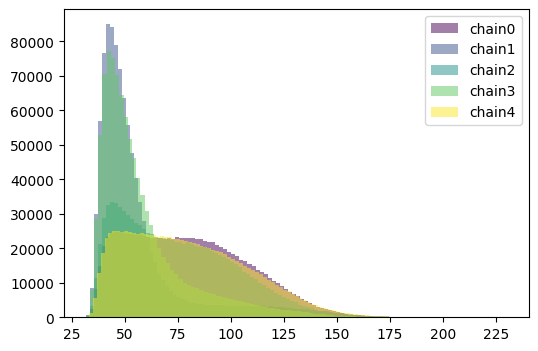

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(energy_values[i, :], color = colors[i], alpha = 0.5, label = f"chain{i}", bins = 100)
plt.legend()
plt.show()   

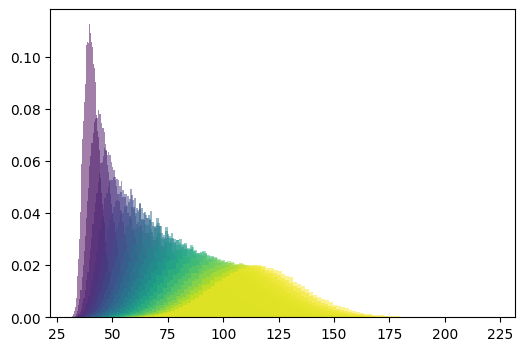

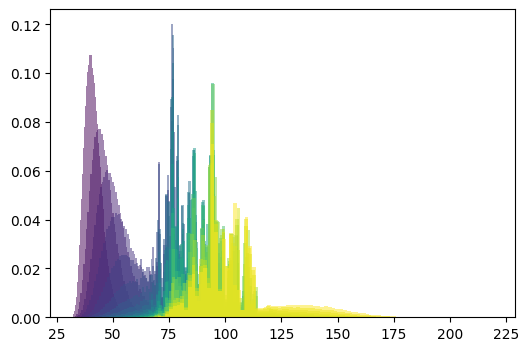

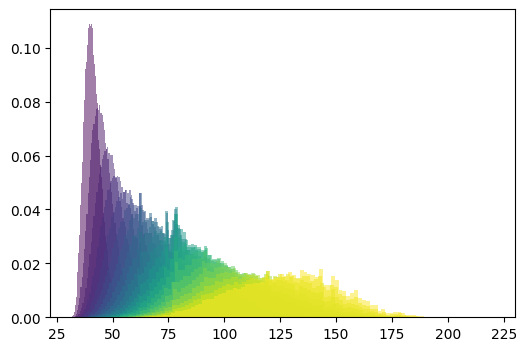

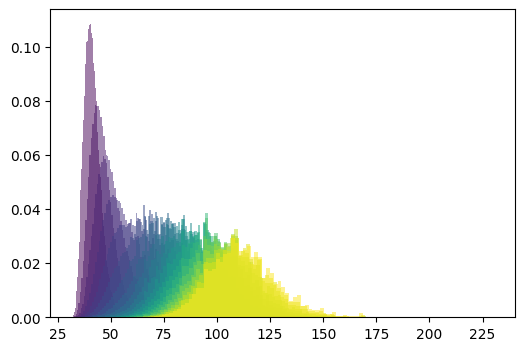

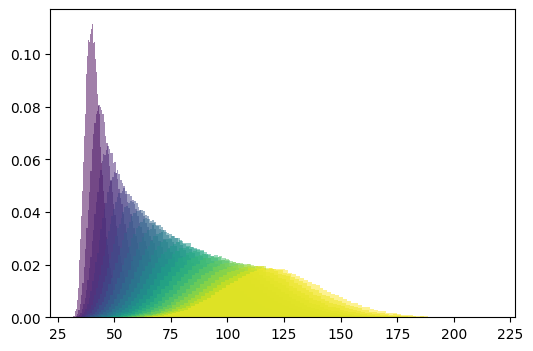

In [ ]:
if nt > 1:
    limit_grid = np.linspace(80, 190, 100)
    bin_grid = limit_grid[:-1]
    mean_energies = np.zeros((config["nch"], nt))
    energy_stds = np.zeros((config["nch"], nt))

    for k in range(config["nch"]):
        fig, ax = plt.subplots(figsize=(6, 4))
        for j in range(nt):
            # bin_values = np.zeros_like(bin_grid)
            # weights = np.exp(-(betas[j] - beta0) * energy_values[k, :] + bias_values[k, :])
            # for bin_idx in range(len(bin_grid)):
            #     for i, e in enumerate(energy_values[k, :]):
            #         if e > limit_grid[bin_idx] and e < limit_grid[bin_idx + 1]:
            #             bin_values[bin_idx] += weights[i]
            # print(sum(weights))
            # bin_values /= sum(weights)
            # # print(bin_values)
            # ax.plot(bin_grid + ((190-80)/100), bin_values, color = temp_colors[j])
            ax.hist(energy_samples[j, k, :], bins = 100, color = temp_colors[j], label = f"temp {temp_centers[j]}", alpha = 0.5, density = True)
            mean_energies[k,j]  = np.mean(energy_samples[j,k,:])
            energy_stds[k,j]  = np.std(energy_samples[j, k, :])
        
        # plt.legend()
        if config["ns"]>=100000:    
            plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/temp_pic_chain_{k}.jpg")
        plt.show()

[[ 41.1840549   49.77930646  64.36321933  85.46742813 116.30719949]
 [ 41.17986522  49.64495648  64.37443631  85.68813541 113.25150219]
 [ 41.39201411  50.8239509   68.95318521  87.68312675 104.6938173 ]
 [ 41.1779      49.86109116  66.17581135 114.73629278 135.10180986]
 [ 41.20252497  49.98081808  65.66602204  88.62416748 120.08971956]]
[[ 3.86791088  6.54121764  9.92335887 14.36199493 21.62643027]
 [ 3.8720794   6.5049041   9.9842117  14.25554784 20.01487101]
 [ 3.98971483  6.98957284 10.96429099 11.35756265 16.91308747]
 [ 3.8446896   6.77147023 10.82828899 19.12930085 12.53956161]
 [ 3.87579286  6.68394007 10.37828824 14.84083219 21.3044971 ]]
25


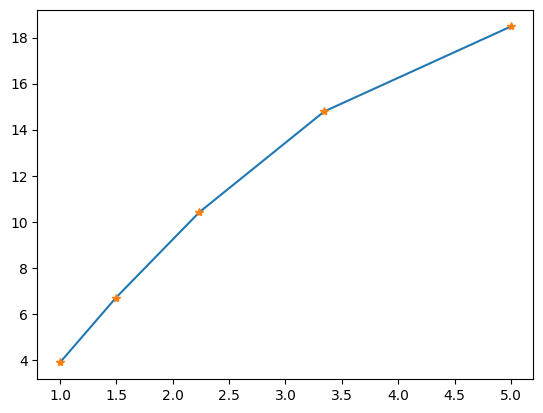

1
1
1
2
2
2
2
3
3
3
3
3
3
3
4
4
4
4
4
4
5
5
5
5
[1, np.float64(1.2540701854290692), np.float64(1.4668779052641279), np.float64(1.660482924375616), np.float64(1.8475891007064267), np.float64(2.030699758506734), np.float64(2.210704555702941), np.float64(2.3882164171454154), np.float64(2.5689034776227375), np.float64(2.7533081792194944), np.float64(2.941100489100245), np.float64(3.1319851250735375), np.float64(3.3256980481812946), np.float64(3.5220031086963273), np.float64(3.7206889349790533), np.float64(3.938581197886454), np.float64(4.16825029442382), np.float64(4.40989386349664), np.float64(4.663664110004379), np.float64(4.929666835654951), np.float64(5.2079613771087265), np.float64(5.4985614124383435), np.float64(5.80143656224853), np.float64(6.1165146842337235), np.float64(6.443684740762397)]
25


In [10]:
print(mean_energies)
print(energy_stds)
min_std = np.min(energy_stds)
N = int(1 + (np.max(mean_energies)- np.min(mean_energies))/min_std)
print(N)
mean_mean_energies = np.mean(mean_energies, axis = 0)
mean_energy_stds = np.mean(energy_stds, axis = 0)
energies = [mean_mean_energies[0]]
Ts = [1]

plt.figure()
plt.plot(temp_centers, mean_energy_stds)
plt.plot(temp_centers, mean_energy_stds, '*')
plt.show()

for i in range(1, N):
    energies.append(energies[i-1] + min_std)
    idx = np.searchsorted(mean_mean_energies, energies[i-1], side = "right")
    print(idx)
    if idx < len(temp_centers):
        T_diff = temp_centers[idx] - temp_centers[idx-1]
        Ts.append(Ts[i-1] + ((min_std * Ts[i-1]**2)/((mean_energy_stds[idx-1] + (Ts[i-1] - temp_centers[idx - 1]) * (mean_energy_stds[idx] - mean_energy_stds[idx - 1])/T_diff)**2)))
    elif idx == len(temp_centers):
        T_diff = temp_centers[idx-1] - temp_centers[idx-2]
        Ts.append(Ts[i-1] + ((min_std * Ts[i-1]**2)/((mean_energy_stds[idx-1] + (Ts[i-1] - temp_centers[idx - 1]) * (mean_energy_stds[idx - 1] - mean_energy_stds[idx - 2])/T_diff)**2)))

# outdir_Ts = base_dir / "../../../../output/{data_name}/{config_find_min_str}"/f"start_Ts.npy"
# np.save(outdir_Ts, Ts)
print(Ts)
print(len(Ts)) # Try running with this!

%matplotlib inline
if (nt > 1 or nl > 1):
    if (not (config["npc"] == None)):

        if config["npc"] == 2:
            xcoords = np.linspace(config["sb"], config["eb"], config["nl"])
            ycoords = np.linspace(config["sb"], config["eb"], config["nl"])

            X, Y = np.meshgrid(xcoords, ycoords)

            for i in range(config["nch"]):
                last_delta_F = np.squeeze(deltaF[i, -1, :, :, 9])
                indices = np.unravel_index(np.argmin(last_delta_F), last_delta_F.shape)
                plt.figure(figsize=(6,5))
                pcm = plt.pcolormesh(X, Y, last_delta_F.T, shading='auto', cmap='viridis') # This looks flipped, could be the plotting, but could also be the indexing.
                plt.colorbar(pcm, label='Value')
                plt.xlabel('X coordinate')
                plt.ylabel('Y coordinate')
                plt.title('2D Plot with coordinates')
                if config["ns"]>=100000:    
                    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/last_deltaF.jpg")
                plt.show()
        if config["npc"] == 1:
            xcoords = np.linspace(config["sb"], config["eb"], config["nl"])

            fig, ax = plt.subplots()

            lines = []

            for j in range(nt):
                line, = ax.plot([], [], lw=2, label=f"T{j}", color = temp_colors[j])
                lines.append(line)
            ax.set_xlim(config["sb"], config["eb"])
            ax.set_ylim(np.min(deltaF), np.max(deltaF))

            ax.set_xlabel("s")
            ax.set_ylabel("delta_F")

            def update(frame):
                i = frame
                for j in range(nt):
                    sample_delta_F = np.squeeze(deltaF[0, i, :, 0, j])
                    lines[j].set_data(xcoords, sample_delta_F)
                ax.set_title(f"sample i={i}")
                return lines,
        
            frames = int(config["ns"]/stride)  # number of frames
            ani = FuncAnimation(fig, update, frames=frames, blit=False, interval=100, repeat = False)
            if config["ns"]>=100000:    
                ani.save(f"../../../../pics/{data_name}/{mid_name}/{config_str}/deltaF_animation.gif", writer="pillow", fps=5)

            plt.show()
    elif nt>1 and nl == 1 and nl2 == 1 and config["ns"] > stride:
        fig, ax = plt.subplots()

        x = np.linspace(0, int(config["ns"]/stride), int(config["ns"]/stride))
        chain = 0
        for k in range(nt):
            sample_delta_F = np.squeeze(deltaF[chain, :, 0, 0, k])
            ax.plot(x, sample_delta_F, '*-', color = temp_colors[k], label = f"T={temp_centers[k]}")

        plt.legend()
        plt.xlabel(f"sample/{stride}")
        plt.ylabel("deltaF")
        if config["ns"]>=100000:    
            plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/deltaF.jpg")
        plt.show()

In [ ]:
# starting_points = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/samples_min_dc2.00_a1.50_b0.21_nch4_N50_H100_nlsp24_mi100000_dt0.00_gl0.00.npy")
# starting_energies = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/Emin_dc2.00_a1.50_b0.21_nch4_N50_H100_nlsp24_mi100000_dt0.00_gl0.00.npy")
starting_energies_path = (base_dir / f"../../../../output/{data_name}/{config_find_min_str}/Emin.npy").resolve()
starting_energies = np.load(starting_energies_path)
starting_points_path = (base_dir / f"../../../../output/{data_name}/{config_find_min_str}/samples_min.npy").resolve()
starting_points= np.load(starting_points_path)

idx = np.argsort(starting_energies)
sp_energies_sorted = starting_energies[idx]

if config["rsp"]:
    sp = np.load(base_dir / f"seed{config["sd"]}/starting_points.npy")
elif not find_min_config["hmc"]:
    sp_energies = sp_energies_sorted[:config["nch"]]
    sp = starting_points[idx][:config["nch"], :]
else:
    outdir_startE = (base_dir / f"../../../../output/{data_name}/{config_find_min_str}/start_energies.npy").resolve() 
    outdir_start_samples = (base_dir / f"../../../../output/{data_name}/{config_find_min_str}/start_samples.npy").resolve() 
    sp_energies_hmc = np.load(outdir_startE)
    sp_hmc = np.load(outdir_start_samples)

    flat_E = sp_energies_hmc.flatten()
    flat_samples = sp_hmc.reshape(find_min_config["nlsp"]*find_min_config["ns"], -1)

    q25, q75 = np.percentile(flat_E, [25, 75])
    candidate_mask = (flat_E >= q25) & (flat_E <= q75)
    candidate_E = flat_E[candidate_mask]
    candidate_samples = flat_samples[candidate_mask]
    np.random.seed(config["sd"])
    indices = np.random.choice(len(candidate_samples), size=config["nch"], replace=False)
    sp = candidate_samples[indices]
    sp_energies = candidate_E[indices]

In [13]:
sp_mean= np.mean(starting_points, axis = 0)
sp_centered = starting_points-sp_mean

cov = np.cov(sp_centered, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]

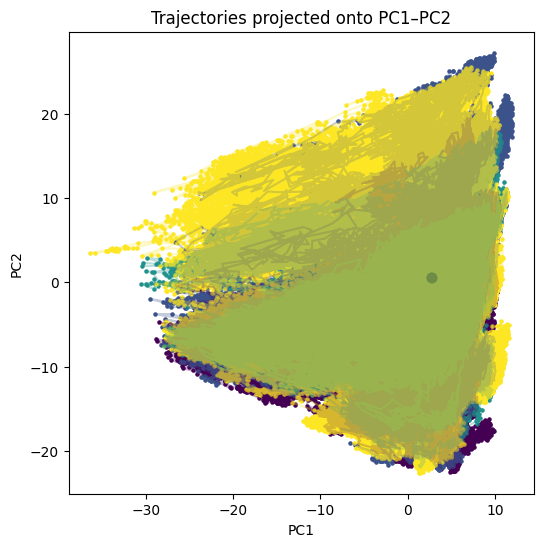

In [ ]:
proj = []
for chain in range(samples.shape[0]):
    traj = samples[chain]
    traj_centered = traj - sp_mean
    coords = np.stack([traj_centered @ pc1,
                       traj_centered @ pc2], axis=1) # This should be the same as what i get when i print in C, maybe the indexing becomes wrong when i send in the pcs?
    proj.append(coords)

# Plot
fig, ax = plt.subplots(figsize=(6,6))

for chain, coords in enumerate(proj):
    ax.plot(coords[:,0], coords[:,1], alpha=0.3, color=colors[chain])
    ax.scatter(coords[:,0], coords[:,1], s=5, color=colors[chain], label=f"chain {chain}")

ax.scatter(sp @ pc1, sp @ pc2, color = 'black', marker = 'o')
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Trajectories projected onto PC1–PC2")
if config["ns"]>=100000:    
    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/trajectory.jpg")
plt.show()

In [ ]:
print(np.shape(resampled_samples))
print(np.shape(samples))
print(f"../../../../pics/{data_name}/{mid_name}/{config_str}")

(5, 999990, 15)
(5, 1000000, 15)
../../../../pics/dayu13A/N15_H30_dc2_a1.5_b0.21_nlsp100_mi100000_gl0.0001_sd42_adt0.0001/N15_H30_dc2_dt0.005_ns1000000_co10_ndt10_nHMC10_nch5_a1.5_b0.21_dE50_sbt1_ebt5_nt5_sd42


In [17]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

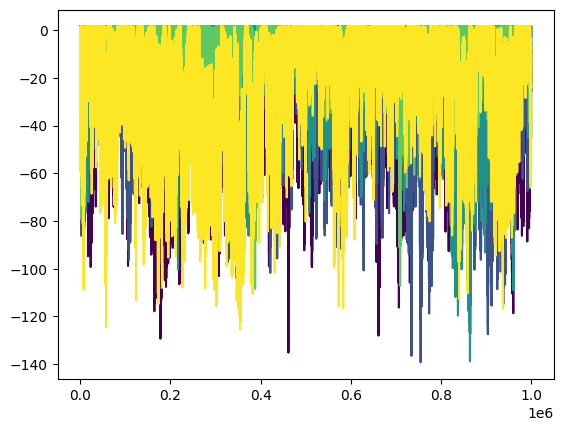

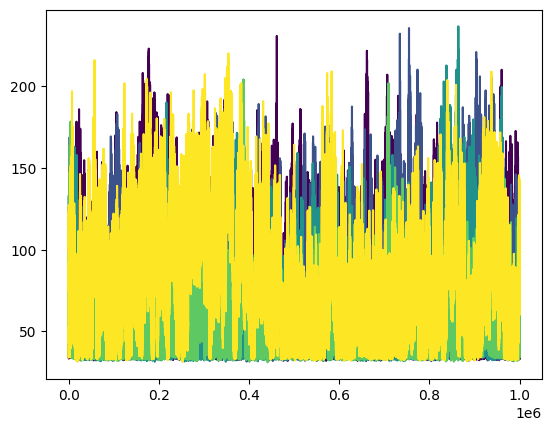

In [ ]:
plt.figure()
for i in range(config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
if config["ns"]>=100000:    
    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/bias.jpg")
plt.show()

plt.figure()
for i in range(config["nch"]):
    plt.plot(energy_values[i,:], color = colors[i])
if config["ns"]>=100000:    
    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/energy.jpg")
plt.show()


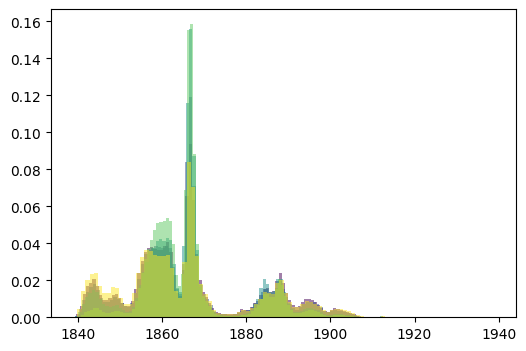

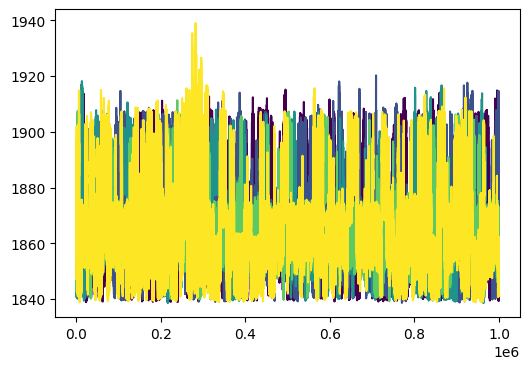

In [ ]:
index = 10
interesting_depth = index * config["dc"]
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :index], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
if config["ns"]>=100000:    
    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/sampling_along_depth_{interesting_depth}.jpg")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
if config["ns"]>=100000:    
    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/sampling_along_depth_evolution_{interesting_depth}.jpg")
plt.show()

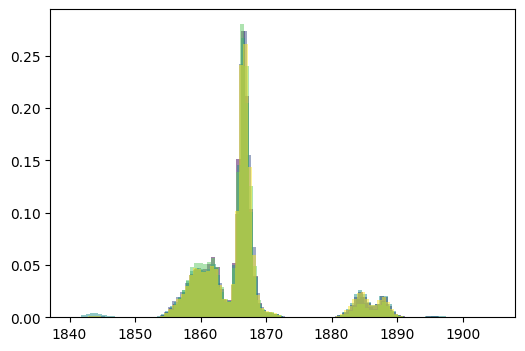

In [ ]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :index], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
if config["ns"]>=100000:    
    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/resampling_along_depth_{interesting_depth}.jpg")
plt.show()

In [21]:
resampled_samples = resampled_samples[:,::100,:]

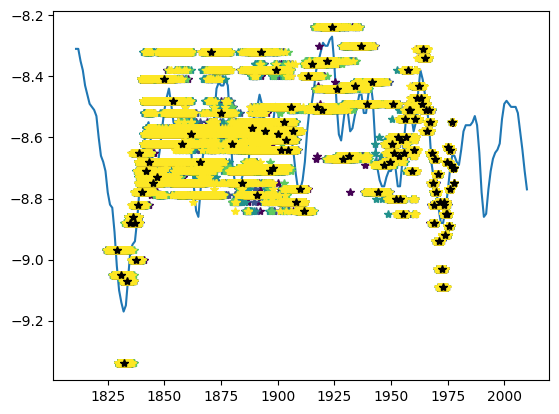

In [22]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"][800:], data["d18O_reference"][800:])
for i in range(config["nch"]):
    variables = resampled_samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [23]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(resampled_samples)
summary = az.summary(idata, round_to=2)
print(summary)

       mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]   2.76  0.23    2.34     3.20       0.00     0.00  50292.32  49934.58   
x[1]   4.65  0.51    3.73     5.63       0.00     0.00  50644.59  49833.71   
x[2]   5.73  0.72    4.41     7.03       0.00     0.00  50788.28  49975.82   
x[3]   6.29  0.83    4.80     7.75       0.00     0.00  49397.00  49051.98   
x[4]   6.88  0.91    5.39     8.61       0.00     0.01  50176.11  49111.50   
x[5]   4.62  1.07    2.75     6.31       0.00     0.01  48952.75  49649.23   
x[6]   4.56  1.46    2.05     7.20       0.01     0.01  49615.88  49589.06   
x[7]   3.53  2.01    0.10     6.92       0.01     0.01  49099.03  50020.05   
x[8]   6.70  2.93    0.68    10.89       0.01     0.01  48234.32  49257.53   
x[9]   9.93  3.33    3.74    16.44       0.02     0.01  48196.29  49729.76   
x[10]  6.29  3.23    0.71    10.84       0.01     0.02  49675.83  49170.63   
x[11]  4.56  3.09    0.09    12.01       0.01     0.02  49139.87

In [24]:
depths = np.sort(np.hstack((0, data["d18O_depths"])))
ages = np.flip(np.hstack((data["theta"], data["true_ages_D18O"]))) # why are they not sorted correctly?
# print(depths)
# print(ages)
sed_rates = [0]
theta = data["theta"]

pre_age = theta
pre_depth = 0
for i in range(1, config["N"] + 1):
    idx = np.searchsorted(depths, config["cs"][i])
    # print(np.sort(depths))
    # print(config["cs"][i])
    # print(idx)
    if idx < len(depths):
        upper_depth = depths[idx - 1]
        age = ages[idx - 1] + ((ages[idx] - ages[idx - 1])/(depths[idx] - depths[idx - 1]))*(config["cs"][i] - depths[idx-1])
        sed_rates.append((pre_age - age) / (config["cs"][i] - config["cs"][i-1]))
        pre_age = age
    else:
        sed_rates.append(config["a"] / config["b"])

exp_ages = theta - np.cumsum(sed_rates) * config["dc"]
print(exp_ages)

[1978.02       1972.096      1962.258      1951.41       1936.43414634
 1923.97       1914.04930233 1906.27714286 1901.55704545 1895.40272727
 1883.95857143 1862.55046512 1845.85166667 1838.68975    1834.33076923
 1820.04505495]


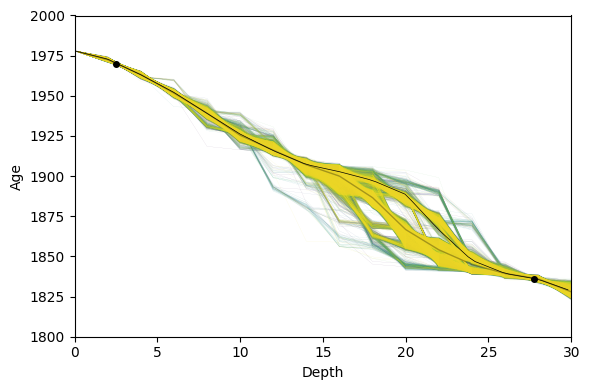

In [ ]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1800, 2000)
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
# plt.plot(config["cs"], exp_ages, color = 'r', linewidth = 0.5)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.plot(data["d18O_depths"], data["true_ages_D18O"], color = 'k', linewidth=0.5)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
if config["ns"]>=100000:
    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/age_depth.jpg")
plt.show()

(5, 16)


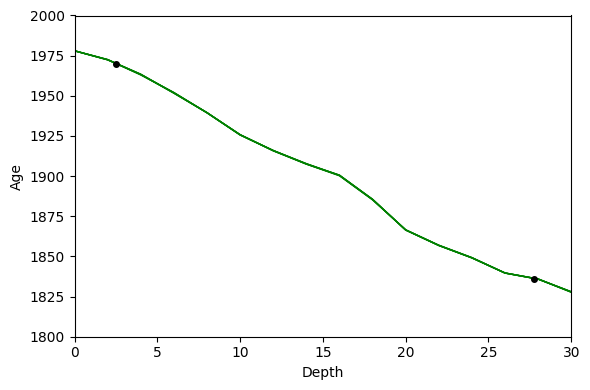

In [ ]:
cumulative_sums = np.cumsum(sp[:,:], axis=1) * config["dc"]
zeros = np.zeros((*sp[:,:].shape[:1], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
print(np.shape(age_offsets))

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(sp[:,0])
for j in range(num_samples):
    ax.plot(
        config["cs"],
        model_ages[j, :],
        color='green',
        alpha=1,
        linewidth=1,
    )
# for i, c in enumerate(config["cs"]):
#     if i != config["pidx"]:
#         ax.axvline(x=c, color='k', linestyle='--')
#     else:
#         ax.axvline(x=c, color='r', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1800, 2000)
# plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
# plt.plot(config["cs"], exp_ages, color = 'r', linewidth = 0.5)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
if config["ns"]>=100000:
    plt.savefig(f"../../../../pics/{data_name}/{mid_name}/{config_str}/sp_age_depth.jpg")
plt.show()